<a href="https://colab.research.google.com/github/riskysurya66-glitch/Prog-Fundamental-Assignment/blob/main/Copy_of_Welcome_to_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scientific Computering

Saving aol_data.xlsx to aol_data (6).xlsx
Model Persamaan:
Persamaan Model:
f(x) = 0.003863x³ -0.134357x² +47.223553x +1748.506723
R² = 0.9956
RMSE = 288.436


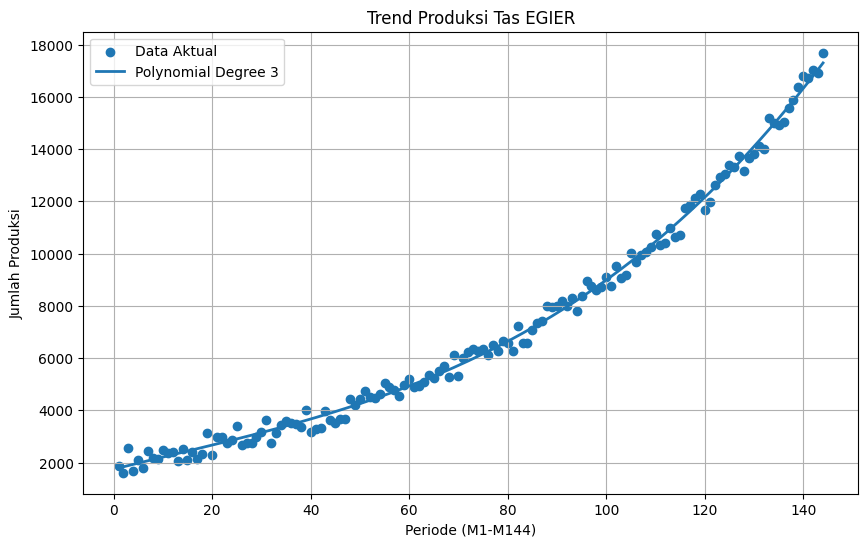

In [ ]:
# @title Number 1. ( Polynomial Regression )
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

from google.colab import files

uploaded = files.upload()

df = pd.read_excel('/content/aol_data.xlsx')

y = df.iloc[0].values
x = np.arange(1, len(y)+1)

degree = 3

coeffs = np.polyfit(x, y, degree)
model = np.poly1d(coeffs)

y_pred = model(x)

r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print("Model Persamaan:")
coeffs = model.coefficients

a = coeffs[0]
b = coeffs[1]
c = coeffs[2]
d = coeffs[3]

print("Persamaan Model:")

print(
    f"f(x) = "
    f"{a:.6f}x³ "
    f"{b:+.6f}x² "
    f"{c:+.6f}x "
    f"{d:+.6f}"
)

print(f"R² = {r2:.4f}")
print(f"RMSE = {rmse:.3f}")

plt.figure(figsize=(10,6))

plt.scatter(x, y, label='Data Aktual')
plt.plot(x, y_pred, linewidth=2, label='Polynomial Degree 3')

plt.xlabel('Periode (M1-M144)')
plt.ylabel('Jumlah Produksi')
plt.title('Trend Produksi Tas EGIER')
plt.legend()
plt.grid(True)

plt.show()

Taylor Approximation (Order 3)
Titik ekspansi a = 72
RMSE Taylor = 0.000


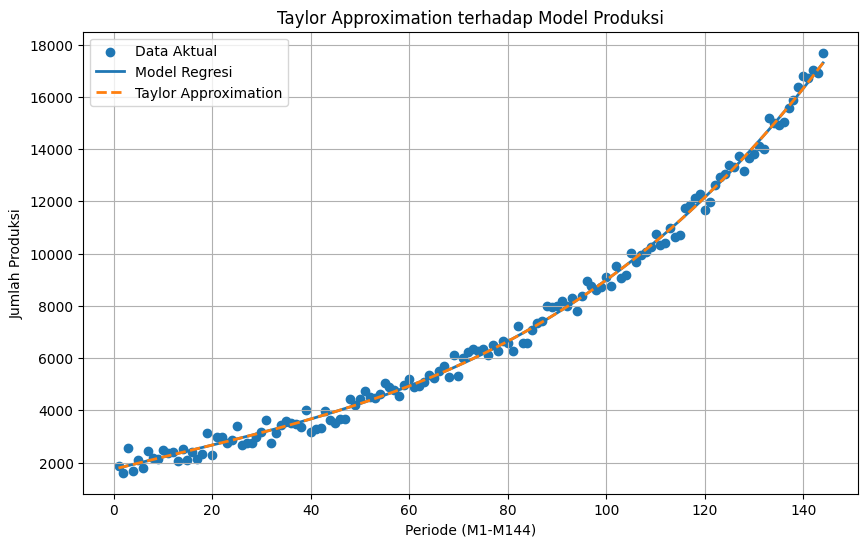

In [ ]:
# @title Number 2. ( Taylor Style )

a0 = 72

first_derivative = np.polyder(model, 1)
second_derivative = np.polyder(model, 2)
third_derivative = np.polyder(model, 3)

f0 = model(a0)
f1 = first_derivative(a0)
f2 = second_derivative(a0)
f3 = third_derivative(a0)

def taylor(x):
    return (
        f0
        + f1*(x-a0)
        + (f2/2)*(x-a0)**2
        + (f3/6)*(x-a0)**3
    )

y_taylor = taylor(x)

rmse_taylor = np.sqrt(mean_squared_error(y_pred, y_taylor))

print("Taylor Approximation (Order 3)")
print(f"Titik ekspansi a = {a0}")
print(f"RMSE Taylor = {rmse_taylor:.3f}")


plt.figure(figsize=(10,6))

plt.scatter(x, y, label='Data Aktual')

plt.plot(x, y_pred, linewidth=2, label='Model Regresi')

plt.plot(x, y_taylor, linestyle='--', linewidth=2, label='Taylor Approximation')

plt.xlabel('Periode (M1-M144)')
plt.ylabel('Jumlah Produksi')
plt.title('Taylor Approximation terhadap Model Produksi')

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# @title Number 3. ( Newton-Raphson )
from scipy import optimize

def g(x):
    return model(x) - 25000

derivative_model = np.polyder(model)

def g_prime(x):
    return derivative_model(x)

x0 = 180

root = optimize.newton(g,x0=x0,fprime=g_prime)

print("Hasil Newton-Raphson")
print(f"Akar persamaan = {root:.3f}")


months = [
    "Jan", "Feb", "Mar", "Apr",
    "Mei", "Jun", "Jul", "Agu",
    "Sep", "Okt", "Nov", "Des"
]

month_index = int(np.ceil(root))

year = 2018 + ((month_index - 1) // 12)
month = months[(month_index - 1) % 12]

print(f"\nGudang akan penuh diprediksi pada... : {month} {year}")

start_build = month_index - 13

build_year = 2018 + ((start_build - 1) // 12)
build_month = months[(start_build - 1) % 12]

print(
    f"memulaikan pembangun gudang: "
    f"{build_month} {build_year}"
)

Hasil Newton-Raphson
Akar persamaan = 170.374

Gudang penuh diprediksi: Mar 2032
Mulai bangun gudang: Feb 2031


In [ ]:
# @title Number 4. ( Simpson and Central Difference )
rom scipy.integrate import simpson
h = 1

months = [
    "Jan", "Feb", "Mar", "Apr",
    "Mei", "Jun", "Jul", "Agu",
    "Sep", "Okt", "Nov", "Des"
]

results = []

for i in range(25, 49):

    derivative = ( model(i + h) - model(i - h)) / (2 * h)

    year = 2018 + ((i - 1) // 12)
    month = months[(i - 1) % 12]

    results.append([month, year, derivative])

print("Rate of Change (2020–2021)\n")

for row in results:
    print(
        f"{row[0]} {row[1]} = {row[2]:.3f} "
    )

max_row = max(results, key=lambda x: x[2])
min_row = min(results, key=lambda x: x[2])

print("\nHighest:")
print(
    f"{max_row[0]} {max_row[1]}"
    f" ({max_row[2]:.3f})"
)

print("\nLowest:")
print(
    f"{min_row[0]} {min_row[1]}"
    f" ({min_row[2]:.3f})"
)

simpson_total = simpson(y, x=x)

actual_total = np.sum(y)

absolute_error = abs(actual_total - simpson_total)
relative_error = (
    absolute_error / actual_total
) * 100


print(
    f"Total Produksi (Simpson) = {simpson_total:.3f} "
)

print(
    f"Total sebenarnya = {actual_total:.3f} "
)

print(
    f"Absolute Error = {absolute_error:.3f}"
)

print(
    f"Relative Error = {relative_error:.6f}%"
)

Rate of Change (2020–2021)

Jan 2020 = 47.753
Feb 2020 = 48.076
Mar 2020 = 48.421
Apr 2020 = 48.790
Mei 2020 = 49.182
Jun 2020 = 49.597
Jul 2020 = 50.035
Agu 2020 = 50.497
Sep 2020 = 50.981
Okt 2020 = 51.489
Nov 2020 = 52.020
Des 2020 = 52.574
Jan 2021 = 53.151
Feb 2021 = 53.752
Mar 2021 = 54.376
Apr 2021 = 55.023
Mei 2021 = 55.693
Jun 2021 = 56.386
Jul 2021 = 57.102
Agu 2021 = 57.842
Sep 2021 = 58.605
Okt 2021 = 59.391
Nov 2021 = 60.200
Des 2021 = 61.032

Highest:
Des 2021 (61.032)

Lowest:
Jan 2020 (47.753)
Total Produksi (Simpson) = 1018830.000 
Total sebenarnya = 1030745.000 
Absolute Error = 11915.000
Relative Error = 1.155960%
